In [1]:
# Libraries
import CoolProp.CoolProp as CP
from scipy.integrate import simpson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Calculate properties for each fluid
fluids   = ['ammonia', 'hydrogen', 'methane', 'nitrogen']
pressure = 100000 # Pa
ranges_temperature = [[250, 400], [100, 400], [120, 400], [100, 400]]

In [4]:
# Initialize lists to store coefficients
coeffs_kV_list = []
coeffs_rhoV_list = []
coeffs_cpV_list = []

for i in range(len(fluids)):
    T_vec = np.linspace(ranges_temperature[i][0], ranges_temperature[i][1], 200)
    rho_V = [CP.PropsSI('D','P', pressure,'T',T, fluids[i]) for T in T_vec]
    cp_V  = [CP.PropsSI('C','P', pressure,'T', T, fluids[i]) for T in T_vec]
    k_V   = [CP.PropsSI('L','P', pressure,'T', T, fluids[i]) for T in T_vec]

    coeffs_kV_list.append(np.polyfit(T_vec, k_V, 4))
    coeffs_rhoV_list.append(np.polyfit(T_vec, rho_V, 4))
    coeffs_cpV_list.append(np.polyfit(T_vec, cp_V, 6))

# Convert lists to DataFrames with fluids as columns and polynomial weights as rows
df_coeffs_kV = pd.DataFrame(np.array(coeffs_kV_list).T, columns=fluids)
df_coeffs_rhoV = pd.DataFrame(np.array(coeffs_rhoV_list).T, columns=fluids)
df_coeffs_cpV = pd.DataFrame(np.array(coeffs_cpV_list).T, columns=fluids)

# Rename rows to x^n format (polynomial degree)
df_coeffs_kV.index = [f'x^{i}' for i in range(len(df_coeffs_kV.index)-1, -1, -1)]
df_coeffs_rhoV.index = [f'x^{i}' for i in range(len(df_coeffs_rhoV.index)-1, -1, -1)]
df_coeffs_cpV.index = [f'x^{i}' for i in range(len(df_coeffs_cpV.index)-1, -1, -1)]

# Save to CSV
df_coeffs_kV.to_csv('coeffs_kV.csv')
df_coeffs_rhoV.to_csv( 'coeffs_rhoV.csv')
df_coeffs_cpV.to_csv('coeffs_cpV.csv')



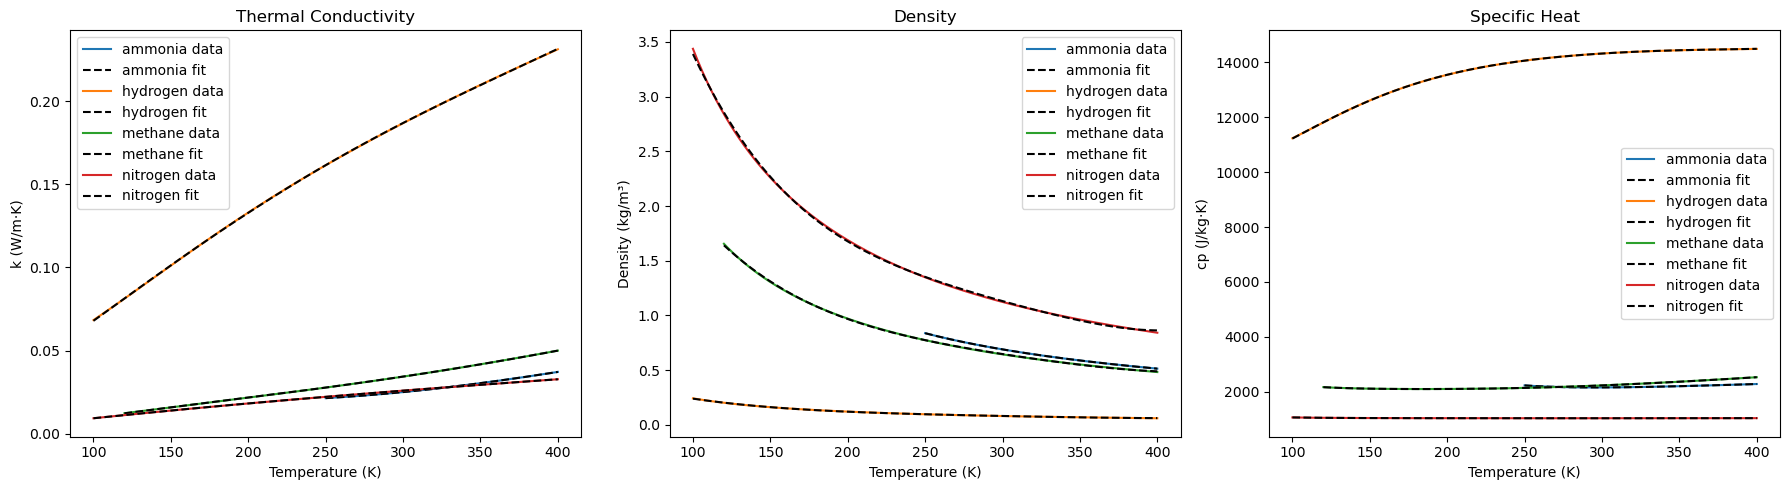

In [40]:
# Plotting the fitting results
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

colors = plt.cm.tab10.colors

for idx, fluid in enumerate(fluids):
    color = colors[idx % len(colors)]
    T_range = np.linspace(ranges_temperature[idx][0], ranges_temperature[idx][1], 200)
    
    poly_kV = np.poly1d(coeffs_kV_list[idx])
    poly_rhoV = np.poly1d(coeffs_rhoV_list[idx])
    poly_cpV = np.poly1d(coeffs_cpV_list[idx])
    
    k_V = [CP.PropsSI('L','P', pressure,'T', T, fluid) for T in T_range]
    rho_V = [CP.PropsSI('D','P', pressure,'T', T, fluid) for T in T_range]
    cp_V = [CP.PropsSI('C','P', pressure,'T', T, fluid) for T in T_range]
    
    axs[0].plot(T_range, k_V, label=f'{fluid} data', color=color)
    axs[0].plot(T_range, poly_kV(T_range), '--', label=f'{fluid} fit', color='k')
    
    axs[1].plot(T_range, rho_V, label=f'{fluid} data', color=color)
    axs[1].plot(T_range, poly_rhoV(T_range), '--', label=f'{fluid} fit', color='k')
    
    axs[2].plot(T_range, cp_V, label=f'{fluid} data', color=color)
    axs[2].plot(T_range, poly_cpV(T_range), '--', label=f'{fluid} fit', color='k')

axs[0].set_title('Thermal Conductivity')
axs[0].set_xlabel('Temperature (K)')
axs[0].set_ylabel('k (W/m·K)')
axs[0].legend()

axs[1].set_title('Density')
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('Density (kg/m³)')
axs[1].legend()

axs[2].set_title('Specific Heat')
axs[2].set_xlabel('Temperature (K)')
axs[2].set_ylabel('cp (J/kg·K)')
axs[2].legend()

plt.tight_layout()
plt.show()
